In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import combinations
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [148]:
df= pd.read_csv("imdb_top_movies_1980_2026.csv")

In [149]:
df.shape

(16252, 9)

In [150]:
df.head()

,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,1994,142.0,Drama,9.3,3182733,https://www.imdb.com/title/tt0111161
1,tt0468569,The Dark Knight,The Dark Knight,2008,152.0,"Action,Crime,Drama",9.1,3161984,https://www.imdb.com/title/tt0468569
2,tt1375666,Inception,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,2811692,https://www.imdb.com/title/tt1375666
3,tt0137523,Fight Club,Fight Club,1999,139.0,"Crime,Drama,Thriller",8.8,2601984,https://www.imdb.com/title/tt0137523
4,tt0816692,Interstellar,Interstellar,2014,169.0,"Adventure,Drama,Sci-Fi",8.7,2521607,https://www.imdb.com/title/tt0816692


In [151]:
df.columns.tolist()

['imdb_id',
 'title',
 'original_title',
 'year',
 'runtime_minutes',
 'genres',
 'average_rating',
 'num_votes',
 'imdb_url']

In [152]:
df.dtypes

imdb_id                str
title                  str
original_title         str
year                 int64
runtime_minutes    float64
genres                 str
average_rating     float64
num_votes            int64
imdb_url               str
dtype: object

In [153]:
df.isna().sum()

imdb_id            0
title              0
original_title     0
year               0
runtime_minutes    1
genres             6
average_rating     0
num_votes          0
imdb_url           0
dtype: int64

In [154]:
df.duplicated().sum()

np.int64(0)

In [155]:
df[["year", "runtime_minutes", "average_rating", "num_votes"]].describe()

,year,runtime_minutes,average_rating,num_votes
count,16252.000000,16251.000000,16252.000000,1.625200e+04
mean,2008.790118,109.147376,6.395194,6.633172e+04
std,11.581006,22.110801,1.050908,1.557366e+05
min,1980.000000,43.000000,1.000000,5.000000e+03
25%,2001.000000,94.000000,5.800000,8.397500e+03
50%,2011.000000,104.000000,6.500000,1.726600e+04
75%,2018.000000,119.000000,7.100000,5.386725e+04
max,2026.000000,566.000000,9.300000,3.182733e+06


In [156]:
movies = df.copy()

In [157]:
movies = movies.drop_duplicates()

In [158]:
numeric_columns = [
    "year",
    "runtime_minutes",
    "average_rating",
    "num_votes",
]

for column in numeric_columns:
    movies[column] = pd.to_numeric(
        movies[column],
        errors="coerce",
    )


In [159]:
# Remove rows where important information is missing
movies = movies.dropna(
    subset=[
        "imdb_id",
        "title",
        "year",
        "average_rating",
        "num_votes",
    ]
).copy()


In [160]:
# Fill missing runtime with median runtime
runtime_median = movies["runtime_minutes"].median()

movies["runtime_minutes"] = (
    movies["runtime_minutes"].fillna(runtime_median)
)

In [161]:
# Fill missing genres
movies["genres"] = movies["genres"].fillna("Unknown")

In [162]:
# Fill missing original titles
movies["original_title"] = (
    movies["original_title"].fillna(movies["title"])
)


In [163]:
# Remove extra spaces from text columns
text_columns = [
    "title",
    "original_title",
    "genres",
]

for column in text_columns:
    movies[column] = (
        movies[column]
        .astype(str)
        .str.strip()
    )


In [164]:
# Remove duplicate IMDb IDs
movies = movies.drop_duplicates(
    subset="imdb_id",
    keep="first",
)

In [165]:
# Reset row indexes
movies = movies.reset_index(drop=True)

In [166]:
movies.shape

(16252, 9)

In [167]:
movies.isna().sum()

imdb_id            0
title              0
original_title     0
year               0
runtime_minutes    0
genres             0
average_rating     0
num_votes          0
imdb_url           0
dtype: int64

In [168]:
#Perform exploratory data analysis

In [169]:
# Movies released per year

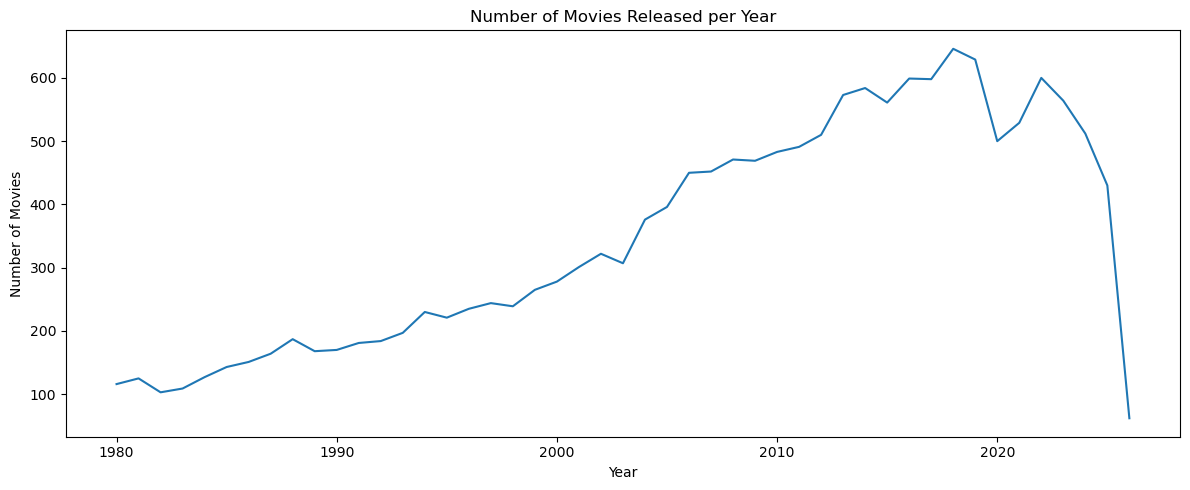

In [170]:
movies_per_year = (
    movies["year"]
    .value_counts()
    .sort_index()
)


plt.figure(figsize=(12, 5))

plt.plot(
    movies_per_year.index,
    movies_per_year.values,
)

plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.tight_layout()

In [171]:
# Most frequent genres


Top 15 genres:
genres
Drama        9219
Comedy       5874
Action       3941
Crime        3256
Thriller     2776
Romance      2652
Adventure    2337
Horror       2193
Mystery      1754
Biography    1130
Fantasy      1091
Sci-Fi        963
Animation     751
Family        659
History       628
Name: count, dtype: int64


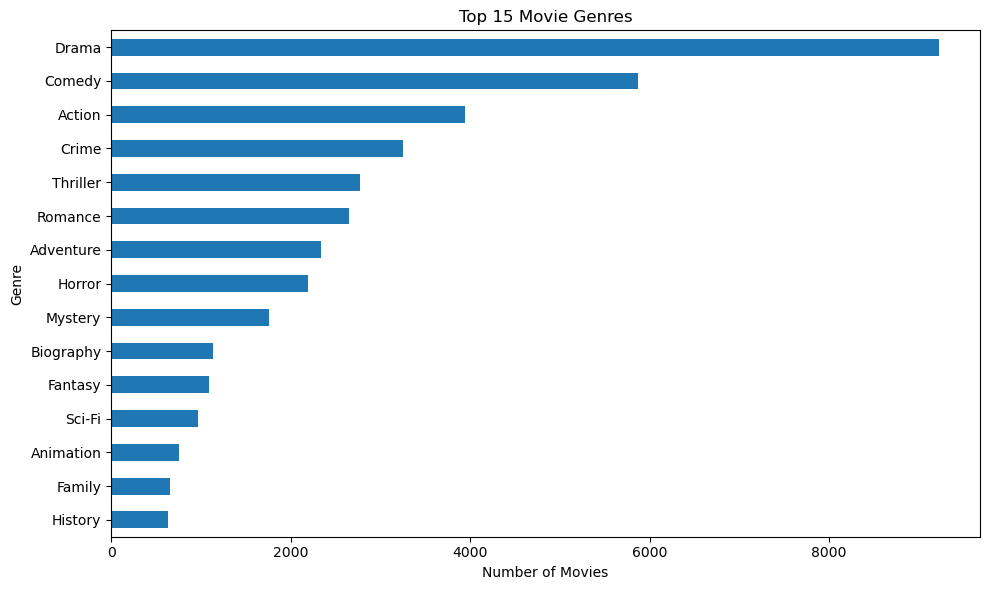

In [172]:
genre_counts = (
    movies["genres"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)


print("\nTop 15 genres:")
print(genre_counts.head(15))


plt.figure(figsize=(10, 6))

genre_counts.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.tight_layout()


In [173]:
# IMDb rating distribution

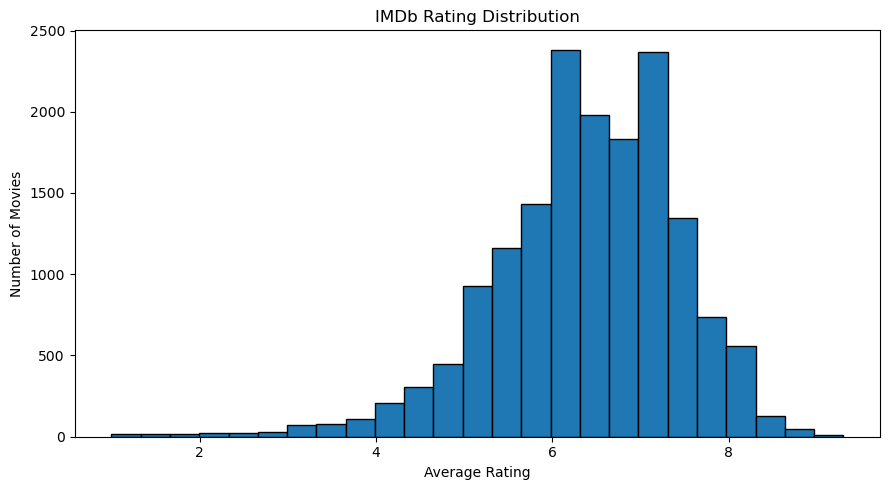

In [174]:
plt.figure(figsize=(9, 5))

plt.hist(
    movies["average_rating"],
    bins=25,
    edgecolor="black",
)

plt.title("IMDb Rating Distribution")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")

plt.tight_layout()

In [175]:
# Runtime distribution

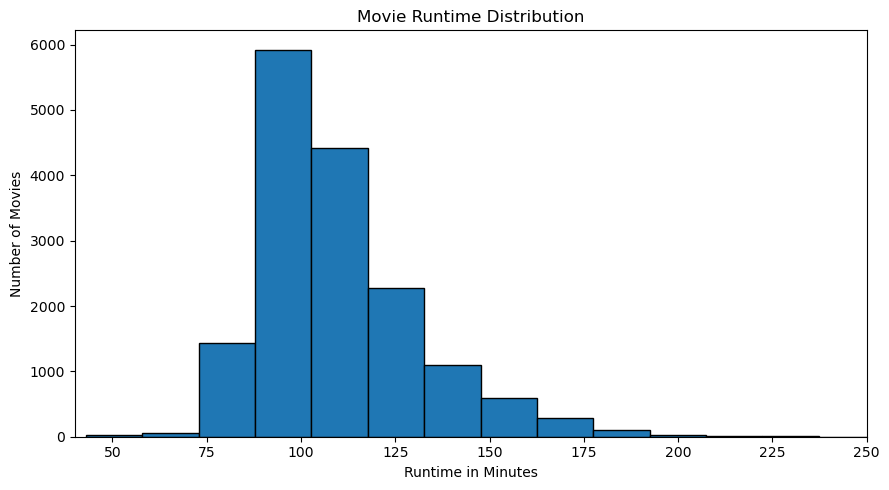

In [176]:
plt.figure(figsize=(9, 5))

plt.hist(
    movies["runtime_minutes"],
    bins=35,
    edgecolor="black",
)

plt.title("Movie Runtime Distribution")
plt.xlabel("Runtime in Minutes")
plt.ylabel("Number of Movies")

# Avoid extreme outliers making the graph unreadable
plt.xlim(40, 250)

plt.tight_layout()

In [177]:
# Rating VS popularity

In [178]:
#The number of votes is highly skewed, so we use a logarithmic transformation.

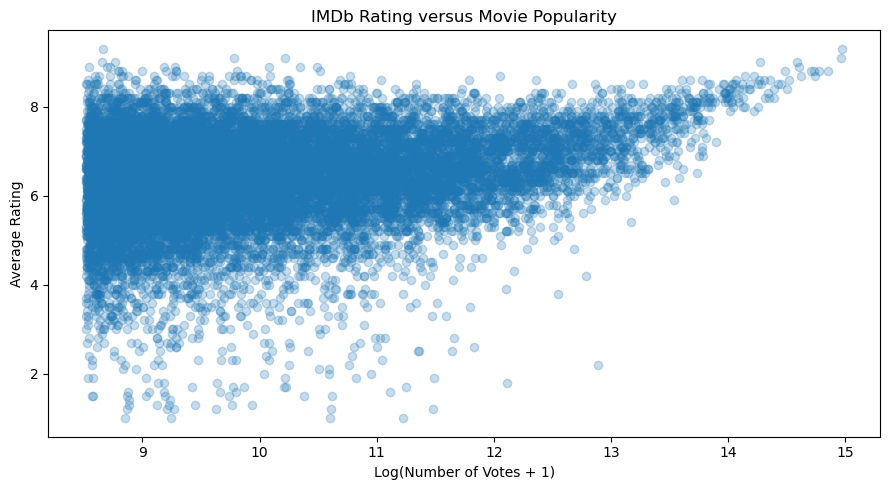

In [179]:
plt.figure(figsize=(9, 5))

plt.scatter(
    np.log1p(movies["num_votes"]),
    movies["average_rating"],
    alpha=0.25,
)

plt.title("IMDb Rating versus Movie Popularity")
plt.xlabel("Log(Number of Votes + 1)")
plt.ylabel("Average Rating")

plt.tight_layout()

In [180]:
# Correlation matrix

In [181]:
correlation_columns = [
    "year",
    "runtime_minutes",
    "average_rating",
    "num_votes",
]


correlation_matrix = movies[
    correlation_columns
].corr()


print("\nCorrelation matrix:")
print(correlation_matrix.round(3))


Correlation matrix:
                  year  runtime_minutes  average_rating  num_votes
year             1.000            0.101          -0.094     -0.040
runtime_minutes  0.101            1.000           0.312      0.171
average_rating  -0.094            0.312           1.000      0.262
num_votes       -0.040            0.171           0.262      1.000


In [182]:
# Convert genres into sets

In [183]:
def split_genres(value):
    genre_set = {
        genre.strip()
        for genre in str(value).split(",")
        if genre.strip()
    }

    if not genre_set:
        return {"Unknown"}

    return genre_set


movies["genre_set"] = (
    movies["genres"].apply(split_genres)
)

In [184]:
# Create decade feature
movies["decade"] = (
    movies["year"] // 10 * 10
).astype(int)

In [185]:
# Create log vote feature
movies["log_votes"] = np.log1p(
    movies["num_votes"]
)

In [186]:
# Create runtime categories
movies["runtime_category"] = pd.cut(
    movies["runtime_minutes"],
    bins=[
        0,
        90,
        120,
        150,
        np.inf,
    ],
    labels=[
        "short",
        "medium",
        "long",
        "very_long",
    ],
    include_lowest=True,
).astype(str)

In [187]:
# Creating Rating categories
movies["rating_category"] = pd.cut(
    movies["average_rating"],
    bins=[
        0,
        5,
        6,
        7,
        8,
        10,
    ],
    labels=[
        "poor",
        "average",
        "good",
        "very_good",
        "excellent",
    ],
    include_lowest=True,
).astype(str)

In [188]:
# Create a popularity category
movies["popularity_category"] = pd.qcut(
    movies["num_votes"],
    q=4,
    labels=[
        "low_popularity",
        "medium_popularity",
        "high_popularity",
        "very_high_popularity",
    ],
    duplicates="drop",
).astype(str)

In [189]:
movies["popularity_category"] = pd.qcut(
    movies["num_votes"],
    q=4,
    labels=[
        "low_popularity",
        "medium_popularity",
        "high_popularity",
        "very_high_popularity",
    ],
    duplicates="drop",
).astype(str)

In [190]:
#Calculate Bayesian weighted rating
#The formula is:

# WR= (v*R)/(v+m) + (m*c)/(v+m)

# Where:

# R = movie rating
# v = number of votes
# C = mean rating of all movies
# m = minimum vote threshold

In [191]:
# Mean rating of all movies
C = movies["average_rating"].mean()

# Minimum vote threshold
m = movies["num_votes"].quantile(0.75)


movies["weighted_rating"] = (
    (
        movies["num_votes"]
        / (movies["num_votes"] + m)
    )
    * movies["average_rating"]
    +
    (
        m
        / (movies["num_votes"] + m)
    )
    * C
)

In [192]:
#Create TF-IDF content text
def build_content_soup(row):
    genre_tokens = [
        genre.lower().replace(" ", "_")
        for genre in sorted(row["genre_set"])
    ]

    # Give genre greater importance
    tokens = genre_tokens * 3

    tokens += [
        f"decade_{row['decade']}",
        f"runtime_{row['runtime_category']}",
        f"rating_{row['rating_category']}",
        f"popularity_{row['popularity_category']}",
    ]

    return " ".join(tokens)


movies["content_soup"] = movies.apply(
    build_content_soup,
    axis=1,
)

In [193]:
print("\nEngineered features:")
movies[
        [
            "title",
            "genres",
            "decade",
            "runtime_category",
            "rating_category",
            "popularity_category",
            "weighted_rating",
            "content_soup",
        ]
    ].head()


Engineered features:


,title,genres,decade,runtime_category,rating_category,popularity_category,weighted_rating,content_soup
0,The Shawshank Redemption,Drama,1990,long,excellent,very_high_popularity,9.251655,drama drama drama decade_1990 runtime_long rat...
1,The Dark Knight,"Action,Crime,Drama",2000,very_long,excellent,very_high_popularity,9.054693,action crime drama action crime drama action c...
2,Inception,"Action,Adventure,Sci-Fi",2010,long,excellent,very_high_popularity,8.754794,action adventure sci-fi action adventure sci-f...
3,Fight Club,"Crime,Drama,Thriller",1990,long,excellent,very_high_popularity,8.751225,crime drama thriller crime drama thriller crim...
4,Interstellar,"Adventure,Drama,Sci-Fi",2010,very_long,excellent,very_high_popularity,8.651794,adventure drama sci-fi adventure drama sci-fi ...


In [194]:
#Jaccard similarity function

def jaccard_similarity(set_a, set_b):
    union = set_a | set_b

    if not union:
        return 0.0

    intersection = set_a & set_b

    return len(intersection) / len(union)

In [195]:
# Function to find a movie
def find_movie(movies_df, title):

    searched_title = title.strip().lower()

    # Search for an exact title match
    exact_matches = movies_df[
        movies_df["title"].str.lower() == searched_title
    ]

    if not exact_matches.empty:

        # Return the most popular result if duplicates exist
        return exact_matches.sort_values(
            by="num_votes",
            ascending=False
        ).iloc[0]

    # Search for partial title matches
    partial_matches = movies_df[
        movies_df["title"]
        .str.lower()
        .str.contains(
            searched_title,
            regex=False,
            na=False
        )
    ]

    if partial_matches.empty:
        raise ValueError(
            f"Movie '{title}' was not found."
        )

    print("\nExact title not found. Possible matches:")

    print(
        partial_matches[
            [
                "title",
                "year",
                "average_rating"
            ]
        ]
        .head(10)
        .to_string(index=False)
    )

    # Return the most popular partial match
    return partial_matches.sort_values(
        by="num_votes",
        ascending=False
    ).iloc[0]
    

In [196]:
OUTPUT_COLUMNS = [
    "imdb_id",
    "title",
    "year",
    "genres",
    "runtime_minutes",
    "average_rating",
    "num_votes",
    "weighted_rating",
    "imdb_url",
]

In [197]:
# Recommendation model class

In [198]:
# Algorithm 1 — Jaccard similarity

In [199]:
def recommend_using_jaccard(
    movie_title,
    top_n=10
):

    # Pass both the dataframe and movie title
    query_movie = find_movie(
        movies,
        movie_title
    )

    recommendation_data = movies.copy()

    recommendation_data[
        "jaccard_similarity"
    ] = recommendation_data[
        "genre_set"
    ].apply(
        lambda candidate_genres:
        jaccard_similarity(
            query_movie["genre_set"],
            candidate_genres
        )
    )

    # Remove the selected movie itself
    recommendation_data = recommendation_data[
        recommendation_data["imdb_id"]
        != query_movie["imdb_id"]
    ]

    recommendations = (
        recommendation_data
        .sort_values(
            by=[
                "jaccard_similarity",
                "weighted_rating",
                "num_votes"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .head(top_n)
    )

    return recommendations[
    [
        "imdb_id",
        "title",
        "year",
        "genres",
        "runtime_minutes",
        "average_rating",
        "num_votes",
        "jaccard_similarity"
    ]
]

In [200]:
# Trial
jaccard_results = recommend_using_jaccard(
    movie_title="Inception",
    top_n=10
)


print("\nJaccard recommendations:")

jaccard_results.to_string(
        index=False
    )


Jaccard recommendations:


'  imdb_id                      title  year                  genres  runtime_minutes  average_rating  num_votes  jaccard_similarity\ntt0103064 Terminator 2: Judgment Day  1991 Action,Adventure,Sci-Fi            137.0             8.6    1282423                 1.0\ntt4154796          Avengers: Endgame  2019 Action,Adventure,Sci-Fi            181.0             8.4    1442673                 1.0\ntt4154756     Avengers: Infinity War  2018 Action,Adventure,Sci-Fi            149.0             8.4    1368811                 1.0\ntt0107290              Jurassic Park  1993 Action,Adventure,Sci-Fi            127.0             8.2    1175723                 1.0\ntt1392190         Mad Max: Fury Road  2015 Action,Adventure,Sci-Fi            120.0             8.1    1204877                 1.0\ntt0088247             The Terminator  1984 Action,Adventure,Sci-Fi            107.0             8.1    1003330                 1.0\ntt0371746                   Iron Man  2008 Action,Adventure,Sci-Fi         

In [201]:
# Create the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[\w-]+\b"
)


# Convert movie content into TF-IDF vectors
tfidf_matrix = tfidf_vectorizer.fit_transform(
    movies["content_soup"]
)


print("TF-IDF matrix created successfully.")

print("Number of movies:", tfidf_matrix.shape[0])
print("Number of TF-IDF features:", tfidf_matrix.shape[1])

TF-IDF matrix created successfully.
Number of movies: 16252
Number of TF-IDF features: 41


In [202]:
def recommend_using_tfidf(
    movie_title,
    top_n=10
):

    # Find the selected movie
    query_movie = find_movie(
        movies,
        movie_title
    )

    # Get the row index of the selected movie
    query_index = query_movie.name

    # Calculate cosine similarity between
    # the selected movie and every other movie
    similarity_scores = cosine_similarity(
        tfidf_matrix[query_index],
        tfidf_matrix
    ).flatten()

    # Create a copy of the dataset
    recommendation_data = movies.copy()

    # Store similarity scores
    recommendation_data[
        "cosine_similarity"
    ] = similarity_scores

    # Remove the selected movie itself
    recommendation_data = recommendation_data[
        recommendation_data["imdb_id"]
        != query_movie["imdb_id"]
    ]

    # Sort movies by similarity score
    recommendations = (
        recommendation_data
        .sort_values(
            by=[
                "cosine_similarity",
                "weighted_rating",
                "num_votes"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .head(top_n)
    )

    # Return useful columns
    return recommendations[
    [
        "imdb_id",
        "title",
        "year",
        "genres",
        "runtime_minutes",
        "average_rating",
        "num_votes",
        "cosine_similarity"
    ]
]

In [203]:
tfidf_results = recommend_using_tfidf(
    movie_title="Inception",
    top_n=10
)


print("\nTF-IDF cosine similarity recommendations:")

print(
    tfidf_results.to_string(
        index=False
    )
)


TF-IDF cosine similarity recommendations:
  imdb_id                              title  year                  genres  runtime_minutes  average_rating  num_votes  cosine_similarity
tt4154756             Avengers: Infinity War  2018 Action,Adventure,Sci-Fi            149.0             8.4    1368811           1.000000
tt1392190                 Mad Max: Fury Road  2015 Action,Adventure,Sci-Fi            120.0             8.1    1204877           0.983645
tt0103064         Terminator 2: Judgment Day  1991 Action,Adventure,Sci-Fi            137.0             8.6    1282423           0.977935
tt0107290                      Jurassic Park  1993 Action,Adventure,Sci-Fi            127.0             8.2    1175723           0.977935
tt4983780                           Maanaadu  2021 Action,Adventure,Sci-Fi            147.0             8.1      27762           0.962506
tt4154796                  Avengers: Endgame  2019 Action,Adventure,Sci-Fi            181.0             8.4    1442673           

In [204]:
# Calculate numerical feature range
# Calculate ranges of numerical features

year_range = (
    movies["year"].max()
    - movies["year"].min()
)

runtime_range = (
    movies["runtime_minutes"].max()
    - movies["runtime_minutes"].min()
)

rating_range = (
    movies["average_rating"].max()
    - movies["average_rating"].min()
)

votes_range = (
    movies["log_votes"].max()
    - movies["log_votes"].min()
)


# Prevent division by zero
year_range = max(year_range, 1)
runtime_range = max(runtime_range, 1)
rating_range = max(rating_range, 1)
votes_range = max(votes_range, 1)


print("Year range:", year_range)
print("Runtime range:", runtime_range)
print("Rating range:", rating_range)
print("Log-votes range:", votes_range)

Year range: 46
Runtime range: 523.0
Rating range: 8.3
Log-votes range: 6.455857962393145


In [205]:
# Gower recommendation function
def recommend_using_gower(
    movie_title,
    top_n=10
):

    # Find the selected movie
    query_movie = find_movie(
        movies,
        movie_title
    )

    # Create a copy of the movie dataset
    recommendation_data = movies.copy()


    # -----------------------------------
    # 1. Genre distance
    # -----------------------------------

    genre_similarity = recommendation_data[
        "genre_set"
    ].apply(
        lambda candidate_genres:
        jaccard_similarity(
            query_movie["genre_set"],
            candidate_genres
        )
    )

    genre_distance = 1 - genre_similarity


    # -----------------------------------
    # 2. Release-year distance
    # -----------------------------------

    year_distance = (
        abs(
            recommendation_data["year"]
            - query_movie["year"]
        )
        / year_range
    )


    # -----------------------------------
    # 3. Runtime distance
    # -----------------------------------

    runtime_distance = (
        abs(
            recommendation_data[
                "runtime_minutes"
            ]
            - query_movie[
                "runtime_minutes"
            ]
        )
        / runtime_range
    )


    # -----------------------------------
    # 4. Rating distance
    # -----------------------------------

    rating_distance = (
        abs(
            recommendation_data[
                "average_rating"
            ]
            - query_movie[
                "average_rating"
            ]
        )
        / rating_range
    )


    # -----------------------------------
    # 5. Popularity distance
    # -----------------------------------

    votes_distance = (
        abs(
            recommendation_data[
                "log_votes"
            ]
            - query_movie[
                "log_votes"
            ]
        )
        / votes_range
    )


    # -----------------------------------
    # Combine all distances
    # -----------------------------------

    recommendation_data[
        "gower_distance"
    ] = (
        0.55 * genre_distance
        + 0.15 * year_distance
        + 0.10 * runtime_distance
        + 0.10 * rating_distance
        + 0.10 * votes_distance
    )


    # Convert distance into similarity
    recommendation_data[
        "gower_similarity"
    ] = (
        1
        - recommendation_data[
            "gower_distance"
        ]
    )


    # Remove the selected movie itself
    recommendation_data = recommendation_data[
        recommendation_data["imdb_id"]
        != query_movie["imdb_id"]
    ]


    # Sort movies
    recommendations = (
        recommendation_data
        .sort_values(
            by=[
                "gower_similarity",
                "weighted_rating",
                "num_votes"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .head(top_n)
    )


    return recommendations[
        [
            "imdb_id",
            "title",
            "year",
            "genres",
            "runtime_minutes",
            "average_rating",
            "num_votes",
            "weighted_rating",
            "gower_similarity"
        ]
    ]

In [206]:
gower_results = recommend_using_gower(
    movie_title="Inception",
    top_n=10
)


print("\nGower-style KNN recommendations:")

print(
    gower_results.to_string(
        index=False
    )
)


Gower-style KNN recommendations:
  imdb_id                                      title  year                  genres  runtime_minutes  average_rating  num_votes  weighted_rating  gower_similarity
tt0371746                                   Iron Man  2008 Action,Adventure,Sci-Fi            126.0             7.9    1222787         7.836506          0.965531
tt0796366                                  Star Trek  2009 Action,Adventure,Sci-Fi            127.0             7.9     638043         7.782846          0.958907
tt1392170                           The Hunger Games  2012 Action,Adventure,Sci-Fi            142.0             7.2    1080200         7.161772          0.958236
tt4154756                     Avengers: Infinity War  2018 Action,Adventure,Sci-Fi            149.0             8.4    1368811         8.324092          0.957752
tt1392190                         Mad Max: Fury Road  2015 Action,Adventure,Sci-Fi            120.0             8.1    1204877         8.027044          0.9

In [207]:
# Compare recommendation from all three algorithms

In [208]:
selected_movie = "Inception"
number_of_recommendations = 10


jaccard_results = recommend_using_jaccard(
    movie_title=selected_movie,
    top_n=number_of_recommendations
)


tfidf_results = recommend_using_tfidf(
    movie_title=selected_movie,
    top_n=number_of_recommendations
)


gower_results = recommend_using_gower(
    movie_title=selected_movie,
    top_n=number_of_recommendations
)

In [209]:
print("\n1. JACCARD SIMILARITY RECOMMENDATIONS")

print(
    jaccard_results.to_string(
        index=False
    )
)


1. JACCARD SIMILARITY RECOMMENDATIONS
  imdb_id                      title  year                  genres  runtime_minutes  average_rating  num_votes  jaccard_similarity
tt0103064 Terminator 2: Judgment Day  1991 Action,Adventure,Sci-Fi            137.0             8.6    1282423                 1.0
tt4154796          Avengers: Endgame  2019 Action,Adventure,Sci-Fi            181.0             8.4    1442673                 1.0
tt4154756     Avengers: Infinity War  2018 Action,Adventure,Sci-Fi            149.0             8.4    1368811                 1.0
tt0107290              Jurassic Park  1993 Action,Adventure,Sci-Fi            127.0             8.2    1175723                 1.0
tt1392190         Mad Max: Fury Road  2015 Action,Adventure,Sci-Fi            120.0             8.1    1204877                 1.0
tt0088247             The Terminator  1984 Action,Adventure,Sci-Fi            107.0             8.1    1003330                 1.0
tt0371746                   Iron Man  2008 A

In [210]:
print("\n2. TF-IDF COSINE SIMILARITY RECOMMENDATIONS")

print(
    tfidf_results.to_string(
        index=False
    )
)


2. TF-IDF COSINE SIMILARITY RECOMMENDATIONS
  imdb_id                              title  year                  genres  runtime_minutes  average_rating  num_votes  cosine_similarity
tt4154756             Avengers: Infinity War  2018 Action,Adventure,Sci-Fi            149.0             8.4    1368811           1.000000
tt1392190                 Mad Max: Fury Road  2015 Action,Adventure,Sci-Fi            120.0             8.1    1204877           0.983645
tt0103064         Terminator 2: Judgment Day  1991 Action,Adventure,Sci-Fi            137.0             8.6    1282423           0.977935
tt0107290                      Jurassic Park  1993 Action,Adventure,Sci-Fi            127.0             8.2    1175723           0.977935
tt4983780                           Maanaadu  2021 Action,Adventure,Sci-Fi            147.0             8.1      27762           0.962506
tt4154796                  Avengers: Endgame  2019 Action,Adventure,Sci-Fi            181.0             8.4    1442673         

In [211]:
print("\n3. GOWER-STYLE KNN RECOMMENDATIONS")

print(
    gower_results.to_string(
        index=False
    )
)


3. GOWER-STYLE KNN RECOMMENDATIONS
  imdb_id                                      title  year                  genres  runtime_minutes  average_rating  num_votes  weighted_rating  gower_similarity
tt0371746                                   Iron Man  2008 Action,Adventure,Sci-Fi            126.0             7.9    1222787         7.836506          0.965531
tt0796366                                  Star Trek  2009 Action,Adventure,Sci-Fi            127.0             7.9     638043         7.782846          0.958907
tt1392170                           The Hunger Games  2012 Action,Adventure,Sci-Fi            142.0             7.2    1080200         7.161772          0.958236
tt4154756                     Avengers: Infinity War  2018 Action,Adventure,Sci-Fi            149.0             8.4    1368811         8.324092          0.957752
tt1392190                         Mad Max: Fury Road  2015 Action,Adventure,Sci-Fi            120.0             8.1    1204877         8.027044          0

In [212]:
# Compare result side by side

In [213]:
comparison_table = pd.DataFrame(
    {
        "Jaccard Recommendations":
            jaccard_results[
                "title"
            ].reset_index(drop=True),

        "TF-IDF Recommendations":
            tfidf_results[
                "title"
            ].reset_index(drop=True),

        "Gower Recommendations":
            gower_results[
                "title"
            ].reset_index(drop=True)
    }
)


comparison_table.index = (
    comparison_table.index + 1
)


print("\nRecommendation comparison:")

print(
    comparison_table.to_string()
)


Recommendation comparison:
       Jaccard Recommendations              TF-IDF Recommendations                       Gower Recommendations
1   Terminator 2: Judgment Day              Avengers: Infinity War                                    Iron Man
2            Avengers: Endgame                  Mad Max: Fury Road                                   Star Trek
3       Avengers: Infinity War          Terminator 2: Judgment Day                            The Hunger Games
4                Jurassic Park                       Jurassic Park                      Avengers: Infinity War
5           Mad Max: Fury Road                            Maanaadu                          Mad Max: Fury Road
6               The Terminator                   Avengers: Endgame         Captain America: The Winter Soldier
7                     Iron Man                            Oblivion             The Hunger Games: Catching Fire
8             Edge of Tomorrow                    Star Trek Beyond                  

In [214]:
#Common recommendation system

In [215]:
def get_movie_recommendations(
    movie_title,
    algorithm="gower",
    top_n=10
):

    algorithm = (
        algorithm
        .strip()
        .lower()
    )


    if algorithm == "jaccard":

        return recommend_using_jaccard(
            movie_title=movie_title,
            top_n=top_n
        )


    elif algorithm in [
        "tfidf",
        "cosine",
        "tfidf_cosine"
    ]:

        return recommend_using_tfidf(
            movie_title=movie_title,
            top_n=top_n
        )


    elif algorithm in [
        "gower",
        "knn",
        "gower_knn"
    ]:

        return recommend_using_gower(
            movie_title=movie_title,
            top_n=top_n
        )


    else:

        raise ValueError(
            "Invalid algorithm. Choose "
            "'jaccard', 'tfidf', or 'gower'."
        )

In [216]:
final_recommendations = get_movie_recommendations(
    movie_title="The Dark Knight",
    algorithm="gower",
    top_n=10
)


print(
    final_recommendations.to_string(
        index=False
    )
)

  imdb_id                  title  year             genres  runtime_minutes  average_rating  num_votes  weighted_rating  gower_similarity
tt1345836  The Dark Knight Rises  2012 Action,Crime,Drama            164.0             8.4    1990793         8.347183          0.969062
tt0372784          Batman Begins  2005 Action,Crime,Drama            140.0             8.2    1710954         8.144912          0.967567
tt0381849           3:10 to Yuma  2007 Action,Crime,Drama            122.0             7.6     350826         7.439633          0.938874
tt0328107            Man on Fire  2004 Action,Crime,Drama            146.0             7.7     419249         7.551440          0.937645
tt1197624    Law Abiding Citizen  2009 Action,Crime,Drama            109.0             7.4     344790         7.264229          0.933710
tt0369339             Collateral  2004 Action,Crime,Drama            120.0             7.5     466946         7.385731          0.931933
tt3397884                Sicario  2015 Ac

In [217]:
# Creating evaluation helper function

In [218]:
# Because the dataset does not contain user history or individual user ratings, metrics such as classification accuracy and F1-score are not suitable.

# We will compare the models using:

# Average genre similarity
# Average release-year difference
# Average runtime difference
# Average recommendation rating
# Response time

In [219]:
def evaluate_recommendations(
    query_movie,
    recommendations,
    similarity_column
):

    genre_similarity_scores = []

    for imdb_id in recommendations["imdb_id"]:

        recommended_movie = movies[
            movies["imdb_id"] == imdb_id
        ].iloc[0]

        genre_score = jaccard_similarity(
            query_movie["genre_set"],
            recommended_movie["genre_set"]
        )

        genre_similarity_scores.append(
            genre_score
        )


    average_genre_similarity = np.mean(
        genre_similarity_scores
    )


    average_year_difference = np.mean(
        abs(
            recommendations["year"]
            - query_movie["year"]
        )
    )


    average_runtime_difference = np.mean(
        abs(
            recommendations[
                "runtime_minutes"
            ]
            - query_movie[
                "runtime_minutes"
            ]
        )
    )


    average_recommendation_rating = (
        recommendations[
            "average_rating"
        ].mean()
    )


    average_model_similarity = (
        recommendations[
            similarity_column
        ].mean()
    )


    return {
        "average_genre_similarity":
            average_genre_similarity,

        "average_year_difference":
            average_year_difference,

        "average_runtime_difference":
            average_runtime_difference,

        "average_recommendation_rating":
            average_recommendation_rating,

        "average_model_similarity":
            average_model_similarity
    }

In [220]:
query_movie = find_movie(
    movies,
    selected_movie
)

In [221]:
start_time = time.perf_counter()

jaccard_results = recommend_using_jaccard(
    selected_movie,
    top_n=10
)

jaccard_time = (
    time.perf_counter()
    - start_time
)

In [222]:
start_time = time.perf_counter()

tfidf_results = recommend_using_tfidf(
    selected_movie,
    top_n=10
)

tfidf_time = (
    time.perf_counter()
    - start_time
)

In [223]:
start_time = time.perf_counter()

gower_results = recommend_using_gower(
    selected_movie,
    top_n=10
)

gower_time = (
    time.perf_counter()
    - start_time
)

In [224]:
jaccard_evaluation = evaluate_recommendations(
    query_movie=query_movie,
    recommendations=jaccard_results,
    similarity_column="jaccard_similarity"
)


tfidf_evaluation = evaluate_recommendations(
    query_movie=query_movie,
    recommendations=tfidf_results,
    similarity_column="cosine_similarity"
)


gower_evaluation = evaluate_recommendations(
    query_movie=query_movie,
    recommendations=gower_results,
    similarity_column="gower_similarity"
)

jaccard_evaluation[
    "execution_time_seconds"
] = jaccard_time


tfidf_evaluation[
    "execution_time_seconds"
] = tfidf_time


gower_evaluation[
    "execution_time_seconds"
] = gower_time

In [225]:
model_comparison = pd.DataFrame(
    [
        {
            "algorithm": "Jaccard",
            **jaccard_evaluation
        },

        {
            "algorithm": "TF-IDF Cosine",
            **tfidf_evaluation
        },

        {
            "algorithm": "Gower KNN",
            **gower_evaluation
        }
    ]
)


print("\nFinal model comparison:")

print(
    model_comparison
    .round(4)
    .to_string(index=False)
)


Final model comparison:
    algorithm  average_genre_similarity  average_year_difference  average_runtime_difference  average_recommendation_rating  average_model_similarity  execution_time_seconds
      Jaccard                       1.0                      9.5                        22.9                           8.14                    1.0000                  0.1672
TF-IDF Cosine                       1.0                      8.4                        19.3                           7.76                    0.9708                  0.0655
    Gower KNN                       1.0                      3.5                        14.2                           7.72                    0.9565                  0.2355


In [226]:
comparison_for_scoring = (
    model_comparison.copy()
)


# Normalize values between 0 and 1
comparison_for_scoring[
    "genre_score"
] = (
    comparison_for_scoring[
        "average_genre_similarity"
    ]
    / comparison_for_scoring[
        "average_genre_similarity"
    ].max()
)


comparison_for_scoring[
    "year_score"
] = (
    1
    - (
        comparison_for_scoring[
            "average_year_difference"
        ]
        / comparison_for_scoring[
            "average_year_difference"
        ].max()
    )
)


comparison_for_scoring[
    "runtime_score"
] = (
    1
    - (
        comparison_for_scoring[
            "average_runtime_difference"
        ]
        / comparison_for_scoring[
            "average_runtime_difference"
        ].max()
    )
)


comparison_for_scoring[
    "rating_score"
] = (
    comparison_for_scoring[
        "average_recommendation_rating"
    ]
    / comparison_for_scoring[
        "average_recommendation_rating"
    ].max()
)

In [227]:
comparison_for_scoring[
    "final_score"
] = (
    0.45
    * comparison_for_scoring[
        "genre_score"
    ]
    +
    0.20
    * comparison_for_scoring[
        "year_score"
    ]
    +
    0.15
    * comparison_for_scoring[
        "runtime_score"
    ]
    +
    0.20
    * comparison_for_scoring[
        "rating_score"
    ]
)

In [228]:
final_ranking = (
    comparison_for_scoring[
        [
            "algorithm",
            "final_score"
        ]
    ]
    .sort_values(
        by="final_score",
        ascending=False
    )
    .reset_index(drop=True)
)


final_ranking.index = (
    final_ranking.index + 1
)


print("\nFinal algorithm ranking:")

print(
    final_ranking
    .round(4)
    .to_string()
)


Final algorithm ranking:
       algorithm  final_score
1      Gower KNN       0.8230
2  TF-IDF Cosine       0.6874
3        Jaccard       0.6500


In [229]:
best_algorithm = (
    final_ranking.iloc[0][
        "algorithm"
    ]
)


print(
    "\nBest balanced algorithm:",
    best_algorithm
)


Best balanced algorithm: Gower KNN
